# Trabajo Práctico Nº1 : Teoría Moderna y Filtrado Activo
Curso: R4052  
Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: Cesar Fuoco  
Grupo: 4

Integrantes: Rodríguez Silvosa, Martín; Little, Martín; Parizek, Alan Nicolás; Marchesi, Matías Sebastián

Autor Alumno particular: Rodríguez Silvosa, Martín

### Objetivos:
Consolidar los conceptos de teoría moderna mediante la implementación circuital.
Simular e implementar el filtro con componentes activos de precisión.
Medir las partes de la función transferencia para frecuencias menores a 100 kHz.

### Descripción:

El trabajo práctico consiste en el diseño, análisis, medición y discusión de un filtro activo con la siguiente plantilla instructiva: (la imagen dice grupo 3 pero es grupo 4)

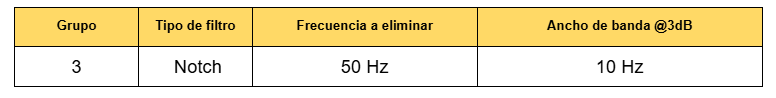

## Parte I : Previo al Laboratorio
### Análisis
1. Obtenga el orden del filtro y $\varepsilon$.
2. Obtenga la función transferencia en el dominio de Laplace. Identifique polos y ceros.
3. Sintetice los valores de los componentes externos del circuito UAF42.

### Simulaciones
1. Realice una simulación numérica/simbólica en Python de la función transferencia.
2. Realice la simulación circuital en LTSpice. Incluya un modelo discreto para simular el UAF42.
3. En ambos casos obtener las gráficas de módulo, fase y retardo y comparar los resultados.


### Armado del circuito
Armar el diseño en un circuito impreso o una placa experimental.
Para el armado tenga en cuenta las siguientes recomendaciones:
- Usar conectores, headers o borneras para poder alimentar el filtro, introducir la señal de entrada, medir la señal de entrada y medir la señal de salida ( test points ).
- Un zócalo DIP14 (de 2x7 pines) para colocar el filtro UAF42 provisto por la Cátedra.
- Incluir resistores variables para realizar el ajuste fino de algún parámetro del diseño.
- En los puntos de alimentación del circuito integrado se recomienda agregar capacitores de bypass. Se sugiere agregar un capacitor electrolítico o de poliéster de 10µF a 68µF con otro cerámico de 100nF a 330nF en paralelo para reducir el ruido de la fuente.

### Parte II : En el Laboratorio
El día de la práctica contarán con el instrumental y los cables de conexión. El setup de medición se detalla a continuación: 

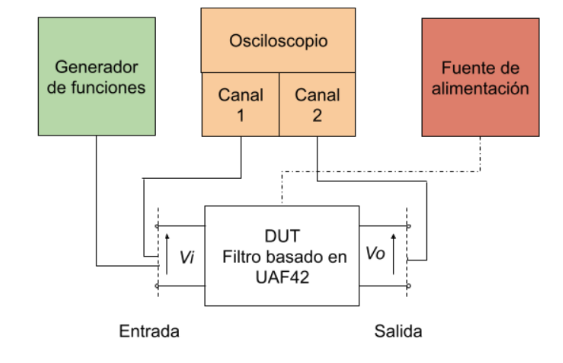

**Pasos a seguir para realizar las mediciones en el laboratorio:**
- 1- Verifique visualmente y con el multímetro que su circuito no tiene cortocircuitos y que los componentes estén correctamente soldados.
- 2- Utilice la limitación de corriente de la fuente en algunas decenas de mA. Para ello se deberán poner en corto los bornes de + y - a una tensión baja por ejemplo 1 V. De esta manera el equipo entra en modo CC ( corto circuito ) y se puede setear el nivel de corriente.
- 3- Calibre la tensión de la fuente. Utilice un multímetro para ajustar la tensión de la fuente. Finalmente alimente su circuito.  Tenga en cuenta que la medición mejora para niveles más altos de fuente.
- 4- Verifique las puntas del osciloscopio. Utilice la señal de prueba tanto en el canal 1 como 2 para ajustar la respuesta temporal visualizada. Verifique el valor de ac y periodo de esta señal de prueba con los medidores del osciloscopio.
- 5- Calibre una señal senoidal en el generador a un nivel que optimice la medición en la banda de paso de valor medio nulo con el generador. Tenga en cuenta que el filtro puede generar sobretensiones a la salida.
- 6- Elija una frecuencia en la mitad de la banda de paso del diseño asignado. Preferiblemente, realice esta calibración con una impedancia de carga del generador de 1 k o más.
- 7- Desenergice el circuito si así estuviera y conecte el integrado. Conecte la alimentación nuevamente y el generador de entrada.
- 8- Verifique con el osciloscopio que tiene señal a la salida. Debe ser de la misma forma que la entrada con una fase y alguna diferencia de amplitud probablemente.
- 9- Realice un barrido en frecuencia sobre su filtro rápido y cualitativo. Verifique que la señal de salida se atenúa cuando barre con frecuencia el filtro.

## Desarrollo
### Parte 1 Análisis (componentes visualizables en el circuito LTSpice):

\begin{equation}
\alpha_{max} = 3dB , \space tomaremos \space \varepsilon = 1
\end{equation}

\begin{equation}
\alpha_{min} = \space ? \space (no \space especifica)
\end{equation}

\begin{equation}
Elegimos \space topología \space multifiltro; \space transformación \space a \space Notch;
\end{equation}

\begin{equation}
Tomaremos \space n = 1 \space por \space duplicación \space del \space orden \space total; 
\end{equation}

\begin{equation}
Bandwith = 10 \space Hz , \space tomaremos \space Q = 5;
\end{equation}

\begin{equation}
$ = {\frac{1}{Q}}{\frac{S}{{S}^2+1}}
\end{equation}

\begin{equation}
T({$}) = \frac{1}{{$}+1}
\end{equation}

$$
T(S) = \left. T(\$) \right|_{\$ = {\frac{1}{Q}}{\frac{S}{{S}^2+1}}} = \frac{1}{{\frac{1}{Q}}{\frac{S}{{S}^2+1}}+1}
$$

$$
T(S) = \frac{Q(S^2+1)}{S+Q(S^2+1)}
$$

$$
T(S) = \frac{Q}{Q} \cdot \frac{S^2+1}{S^2+ S \cdot \frac{1}{Q} + 1}
$$

$$
Tomando \ ahora \ en \ cuenta \ \omega :
$$

\begin{equation}
T({S}) = \frac{S^2 + {wo}^2}{{S^2}+\frac{wo}{Q}S+{wo}^2}
\end{equation}

$$
B = \omega_2 - \omega_1 = \frac{\omega_0}{Q}
$$

$$
B = 10Hz \rightarrow normalizo \ \frac{10Hz}{50Hz} = \frac{1}{5}
$$

$$
B = \frac{1}{5} = \frac{1}{Q} \rightarrow Q = 5
$$

#### Importación librerías a usar python:

In [2]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import math

In [14]:
import pandas as pd

#### Simulación transferencia multifiltro:

In [3]:
# Parámetros:
Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10, Y11 = sp.symbols("Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10, Y11")
Vi, Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg = sp.symbols("Vi, Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg")
G1, G2, G3, G4, G5, G6, G7, G8, G9, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, G4, G5, G6, G7, G8, G9, C1, C2, wt, w0", real=True, positive=True) 
s = sp.symbols('s')

eq1 = Va*(Y3+Y10+Y1+Y2) - Vi*Y3 - Vb*Y10 - Vb*Y1 - Vf*Y2
eq2 = Va*1
eq3 = Vc*(Y4+Y11) - Vb*Y4 - Vd*Y11
eq4 = Vc*1
eq5 = Ve*(Y5+Y6) - Vd*Y5 - Vf*Y6
eq6 = Ve*1
eq7 = Vg*(Y8+Y7+Y9) - Vb*Y8 - Vi*Y7 - Vo*Y9
eq8 = Vg*1

# 1: Resolver los nodos internos:
solucion = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8], [Vo, Va, Vb, Vc, Vd, Ve, Vf, Vg], dict=True)

# Extraemos la solución del primer (y único) diccionario de la lista
# Buscamos Vo, que estará expresado en función de Vi
Vo_resuelto = solucion[0][Vo]

# Calculamos la transferencia T = Vo / Vi
T = sp.simplify(Vo_resuelto / Vi)

# Impresión en formato original (Admitancias)
print_latex(a_equal_b_latex_s('T(s)', T))

# Sustitución de componentes analógicos
T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: G4,
    Y5: G5,
    Y6: G6,
    Y7: G7,
    Y8: G8,
    Y9: G9,
    Y10: s*C1,
    Y11: s*C2
})

T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

# Factor divisor para simplificar una vez viendo la transferencia resultante:
# (primero hice una pasada sin esto, y la analicé visualmente y me doy cuenta que se puede normalizar con este factor)
divisor = C1*C2*G6*G9

# sp.fraction separa cualquier expresión en una tupla (numerador, denominador)
num, den = sp.fraction(T_s)

# Dividimos cada parte por el factor y expandimos
num_dividido = sp.collect(sp.expand(num / divisor), s, evaluate=sp.simplify)
den_dividido = sp.collect(sp.expand(den / divisor), s, evaluate=sp.simplify)

# Reconstruimos la transferencia
T_s = num_dividido / den_dividido

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

$$
T(s) = - \frac{G7}{G9} \cdot \frac{s^2 + s \cdot (\frac{G1}{C1} - \frac{G3G8}{C1G7}) + \frac{G2G4G5}{C1C2G6}}{s^2 + s \cdot \frac{G1}{C1} + \frac{G2G4G5}{C1C2G6}}
$$

$$
G1=G3=Ga; \ G9=G8=G7=G6=G5=Gb; \ G4=G2=Gc; \ C1=C2=C; \ : 
$$
#### El término $s$ del nominador se cancela con esta disposición de parámetros:
$$
T(s) = - \frac{s^2 + \frac{{Gc}^2}{C^2}}{s^2 + s \cdot \frac{Ga}{C} + \frac{Gc^2}{C^2}}
$$

$$
{\omega_0}^2 = \frac{{Gc}^2}{C^2} \rightarrow \omega_0 = \frac{Gc}{C}
$$

$$
\frac{\omega_0}{Q} = \frac{Ga}{C}
$$

#### Definimos:
$$
Gc = \frac{1}{R}
$$

$$
Ga \cdot Q = \omega_0 \cdot C \rightarrow Ga \cdot Q = Gc \rightarrow R1=R3=R \cdot Q
$$

\begin{equation}
Topología \space multifiltro: \space wo= \frac{1}{RC}
\end{equation}

$$
\omega_0 = 2 \pi \cdot 50Hz = 314.159 \frac{rad}{seg}
$$

\begin{equation}
C1=C2=C=100nF
\end{equation}

\begin{equation}
R=\frac{1}{woC} \rightarrow R = \frac{1}{314.159 \cdot 100nF} = 31830 \Omega \rightarrow R2=R4=R=32K\ohm
\end{equation}

\begin{equation}
R1=R3=R2Q=160K\ohm
\end{equation}

\begin{equation}
R5=R6=R7=R8=R9=10K\ohm
\end{equation}

##### Topología multifiltro, utilizando hasta la sección de eliminabanda, ejemplo de Schhaumann, "Design of analog filters" pág 380:

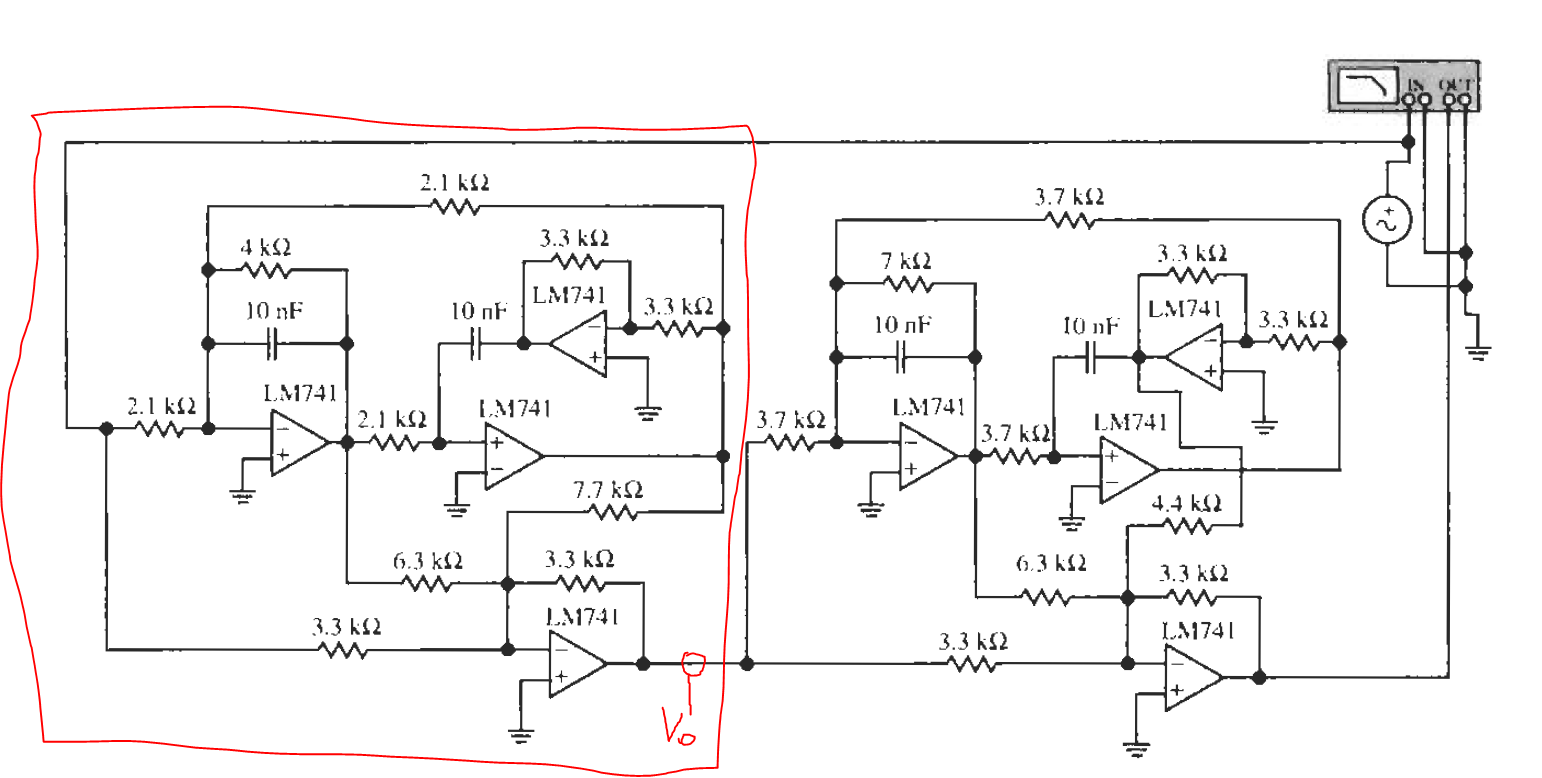

### Simulaciones:

In [4]:
# Setup inline graphics: 

plt.figure(1)
plt.close(1)

# Esto tiene que ver con cuestiones de presentación de los gráficos, para que se vea bonito

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 11

plt.rcParams.update({'font.size':fig_font_size})

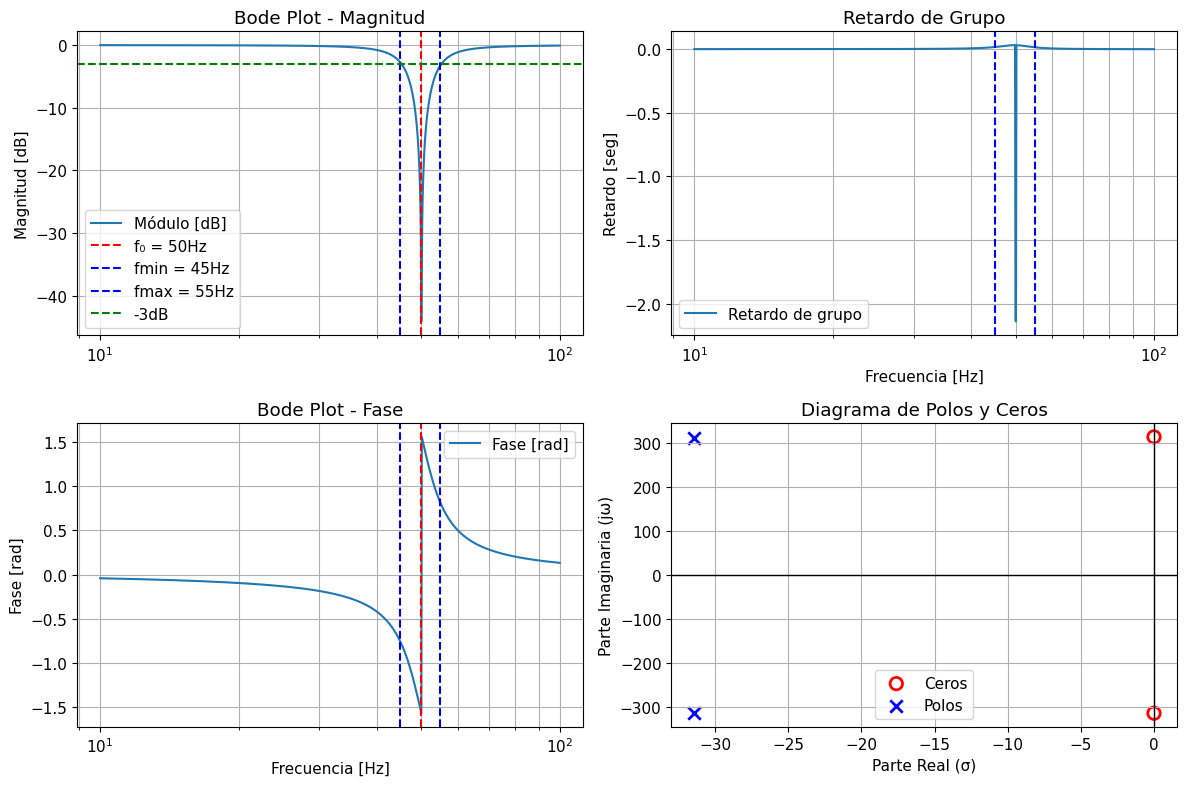

In [10]:
# Definimos los parámetros de la simulación
fo = 50   # Frecuencia central
BW = 10   # Ancho de banda
Q = 5
w0 = 2*np.pi*fo
C = 100e-9
R = 1/(w0*C)

# Coeficientes de la transferencia
num = [1, 0, w0**2]
den = [1, w0/Q, w0**2]

H = sig.TransferFunction(num, den)

# Frecuencia personalizada (espaciada logarítmicamente)
f = np.logspace(1, 2, 1000)           # De 10^1 a 10^2 Hz
w = 2 * np.pi * f                     # En rad/s

# Obtenemos la respuesta en frecuencia
w, mag, phase_deg = sig.bode(H, w)
phase_rad = np.deg2rad(phase_deg)    # Convertimos fase a radianes

# Retardo de grupo por derivada numérica
dphi = np.gradient(phase_rad, w)      # d(phi)/dw
gd = -dphi                            # -d(phi)/dw

# Graficamos (grilla 2x2)
plt.figure(figsize=(12, 8))

# 1. Módulo
plt.subplot(2, 2, 1)
plt.semilogx(f, mag, label='Módulo [dB]')
plt.axvline(x=fo, color='r', linestyle='--', label='f₀ = 50Hz')
plt.axvline(x=fo-5, color='b', linestyle='--', label='fmin = 45Hz')
plt.axvline(x=fo+5, color='b', linestyle='--', label='fmax = 55Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.title('Bode Plot - Magnitud')
plt.ylabel('Magnitud [dB]')
plt.grid(True, which='both')
plt.legend()

# 2. Fase
plt.subplot(2, 2, 3)
plt.semilogx(f, phase_rad, label='Fase [rad]')
plt.axvline(x=fo, color='r', linestyle='--')
plt.axvline(x=fo-5, color='b', linestyle='--')
plt.axvline(x=fo+5, color='b', linestyle='--')
plt.title('Bode Plot - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.grid(True, which='both')
plt.legend()

# 3. Retardo de Grupo
plt.subplot(2, 2, 2)
plt.semilogx(f, gd, linestyle="-", label="Retardo de grupo")
plt.title("Retardo de Grupo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Retardo [seg]")
plt.axvline(x=fo-5, color='b', linestyle='--')
plt.axvline(x=fo+5, color='b', linestyle='--')
plt.grid(True, which="both")
plt.legend()

# 4. Diagrama de polos y ceros
plt.subplot(2, 2, 4)

ceros = H.zeros
polos = H.poles

# Graficamos las raíces en el plano complejo
plt.scatter(np.real(ceros), np.imag(ceros), s=80, marker='o', facecolors='none', edgecolors='r', linewidth=2, label='Ceros')
plt.scatter(np.real(polos), np.imag(polos), s=80, marker='x', color='b', linewidth=2, label='Polos')

# Ejes cartesianos centrales
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, which="both")
plt.title('Diagrama de Polos y Ceros')
plt.xlabel('Parte Real (\u03C3)')
plt.ylabel('Parte Imaginaria (j\u03C9)')
plt.legend()

plt.tight_layout()
plt.show()

### Las simulaciones cumplen con la plantilla especificada (BW 10Hz, Fo 50Hz)

## LTSpice, circuito ensayado y verificación de transferencia:

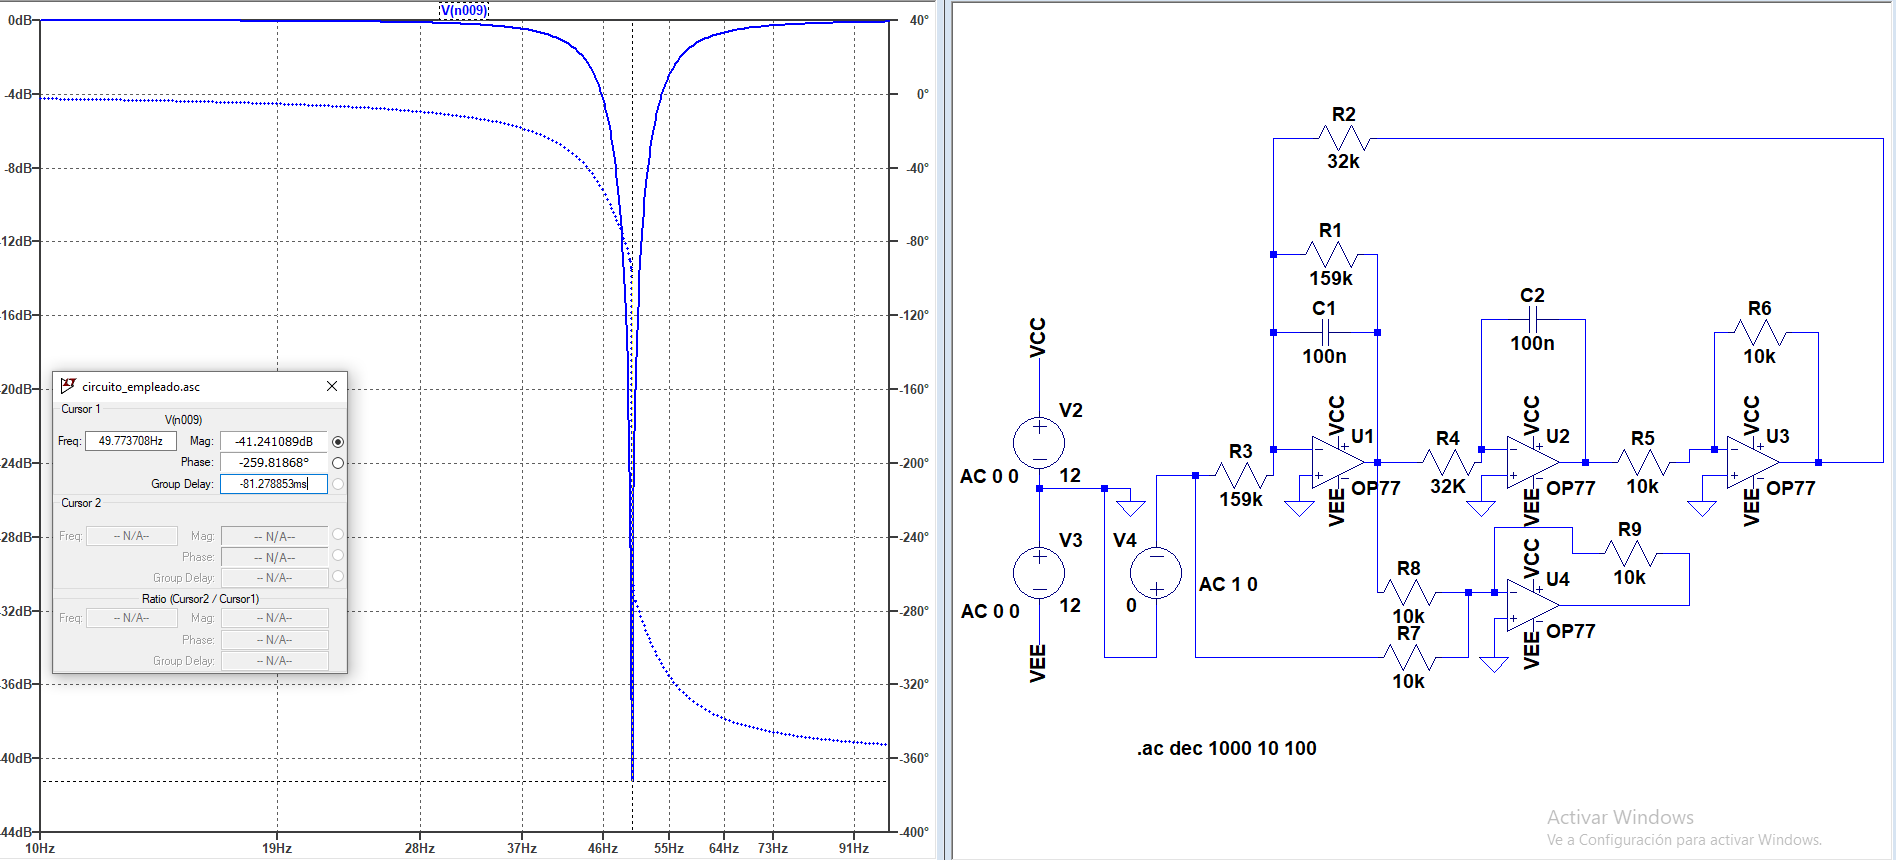

#### El circuito en LTSpice también cumple con los parámetros esperables

## Instrumentos utilizados:


- Multímetro PROSKIT MT-1217.
- Osciloscopio UNI-T GEO21L053.
- Fuente de alimentación EMakers VA150509274 y VA150509068.
- Analizador de audio Agilent U8903A.
- Generador de señales S/N 16G1051212063.


## Componentes utilizados:

- Placa PCB diseñada
- Operacional TL082
- Capacitor cerámico 100nF
- Resistor 10 kΩ 1/4 Watt al 10%
- Resistor 150 kΩ 1/4 Watt al 10%
- Resistor 33 kΩ 1/4 Watt al 10%
- Resistor 5.6 kΩ 1/4 Watt al 10%
- Preset multivueltas de 10kΩ y 50kΩ


#### Características eléctricas TL082, extracto de datasheet Texas Instrument (características suficientes para nuestra aplicación):
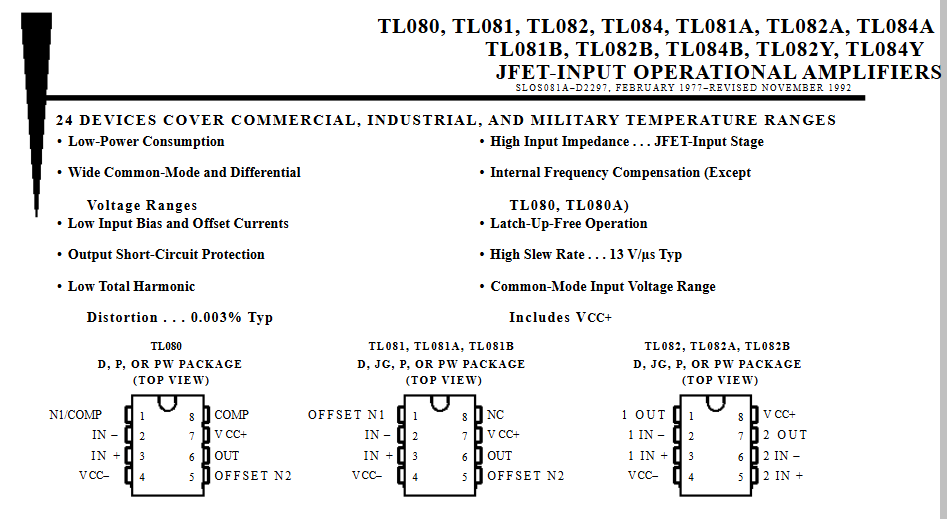
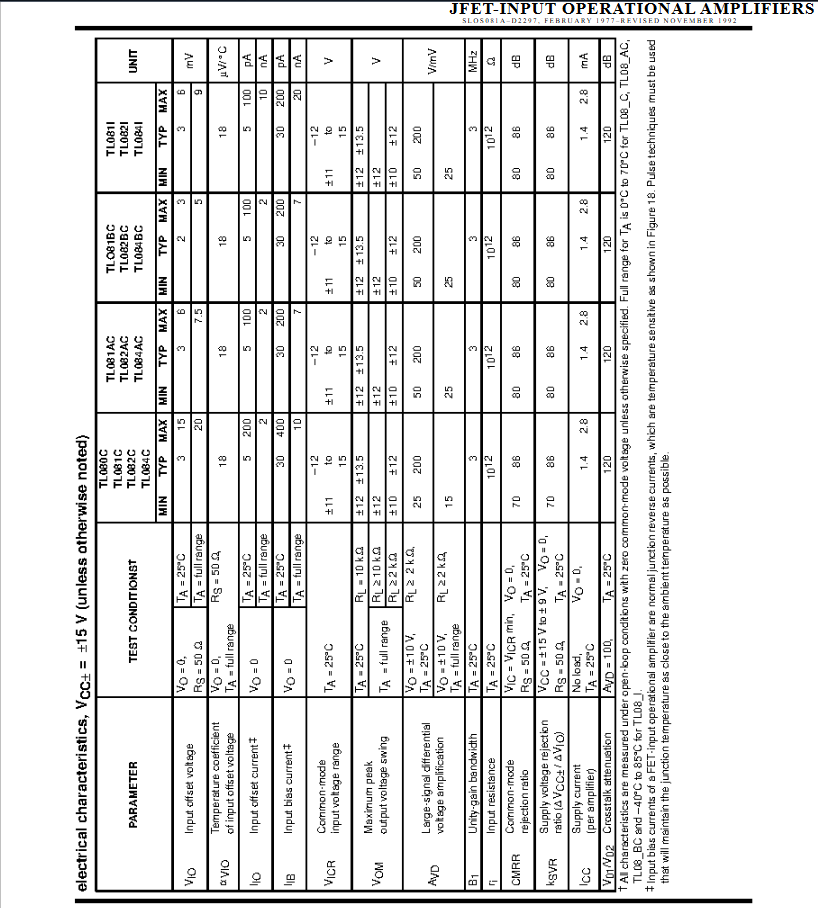

### Placa utilizada utilizando todas las consideraciones listadas:

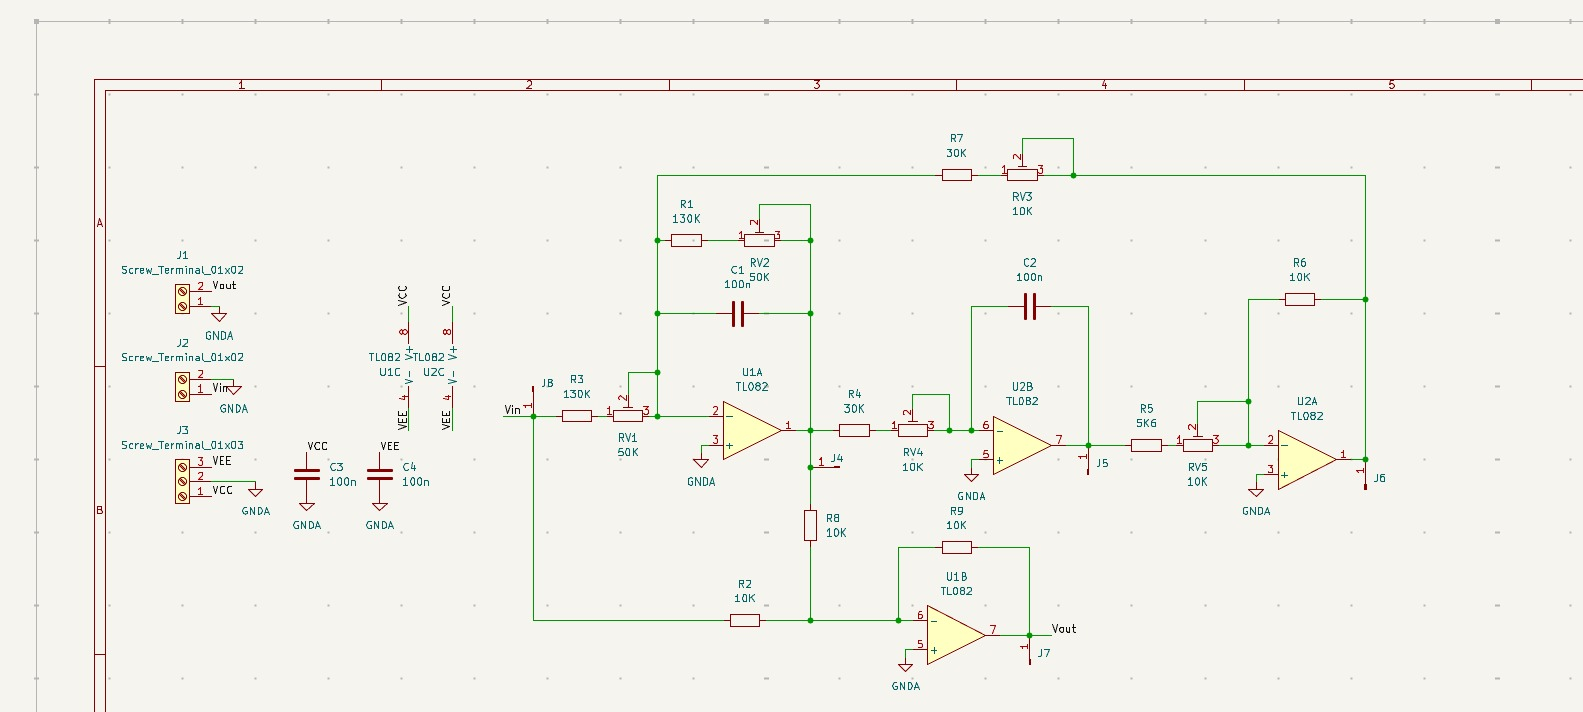

### Mediciones en laboratorio
Se obtuvo la siguiente tabla de resultados:

In [15]:
pd.set_option("display.max_rows", None)   # muestra todas las filas

data = [
    [1, 20, 10, 10, 25.2, 1.00000, 0.00000],
    [2, 40, 10, 9.1, 13.6, 0.91000, -0.81917],
    [3, 57.5, 10, 7.1, 10, 0.71000, -2.97483],
    [4, 59.7, 10, 6, 9.7, 0.60000, -4.43697],
    [5, 61.9, 10, 5.32, 9.3, 0.53200, -5.48177],
    [6, 64.1, 10, 4.51, 8.9, 0.45100, -6.91647],
    [7, 66.3, 10, 3.64, 8.2, 0.36400, -8.77797],
    [8, 68.5, 10, 2.95, 7.3, 0.29500, -10.60356],
    [9, 69.6, 10, 2.83, 6.7, 0.28300, -10.96427],
    [10, 70.7, 10, 3.07, 7.5, 0.30700, -10.25723],
    [11, 72.9, 10, 4, 7.7, 0.40000, -7.95880],
    [12, 75.1, 10, 5.5, 7.8, 0.55000, -5.19275],
    [13, 77.3, 10, 6.48, 7.6, 0.64800, -3.76850],
    [14, 79.5, 10, 7.2, 7.4, 0.72000, -2.85335],
    [15, 80.8, 10, 7.1, 7.2, 0.71000, -2.97483],
    [16, 100, 10, 9.27, 5.5, 0.92700, -0.65841],
    [17, 150, 10, 9.27, 3.48, 0.92700, -0.65841],
]

columns = [
    "Muestra N°",
    "Frecuencia [Hz]",
    "V_entrada [Vpp]",
    "V_salida [Vpp]",
    "Desfasaje [ms]",
    "Atenuación [Veces]",
    "Atenuación [dB]"
]

df = pd.DataFrame(data, columns=columns)
df.head(36)

,Muestra N°,Frecuencia [Hz],V_entrada [Vpp],V_salida [Vpp],Desfasaje [ms],Atenuación [Veces],Atenuación [dB]
0,1,20.0,10,10.00,25.20,1.000,0.00000
1,2,40.0,10,9.10,13.60,0.910,-0.81917
2,3,57.5,10,7.10,10.00,0.710,-2.97483
3,4,59.7,10,6.00,9.70,0.600,-4.43697
4,5,61.9,10,5.32,9.30,0.532,-5.48177
5,6,64.1,10,4.51,8.90,0.451,-6.91647
6,7,66.3,10,3.64,8.20,0.364,-8.77797
7,8,68.5,10,2.95,7.30,0.295,-10.60356
8,9,69.6,10,2.83,6.70,0.283,-10.96427
9,10,70.7,10,3.07,7.50,0.307,-10.25723


#### Transferencia resultante práctica:

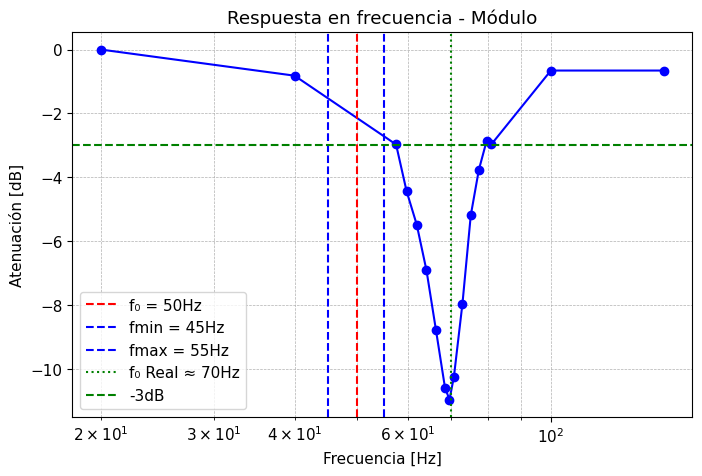

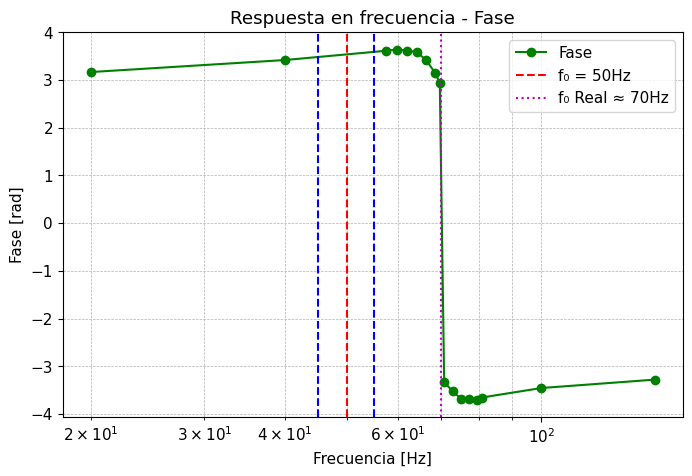

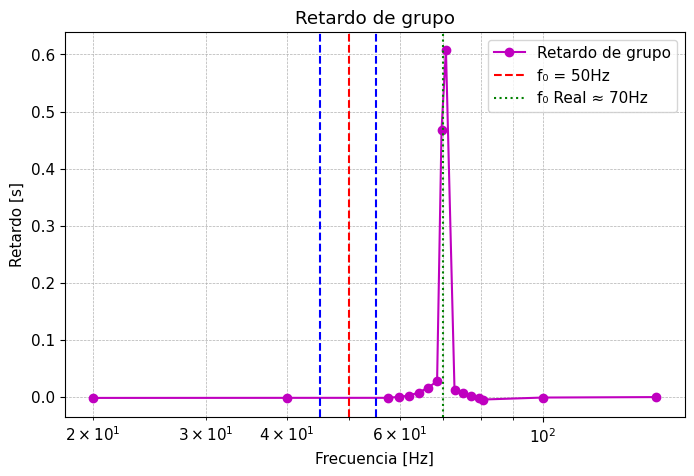

In [21]:
# --- Módulo en dB ---
plt.figure(figsize=(8,5))
plt.semilogx(df["Frecuencia [Hz]"], df["Atenuación [dB]"], marker="o", linestyle="-", color="b")
plt.title("Respuesta en frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Atenuación [dB]")
plt.axvline(x=fo, color='r', linestyle='--', label='f₀ = 50Hz')
plt.axvline(x=fo-5, color='b', linestyle='--', label='fmin = 45Hz')
plt.axvline(x=fo+5, color='b', linestyle='--', label='fmax = 55Hz')
plt.axvline(x=f_resonance_real, color='g', linestyle=':', label='f₀ Real ≈ 70Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

# Frecuencia de resonancia donde ocurre el salto (acá es en donde se ve en la práctica que nos ocurre la frecuencia de eliminación)
f_resonance_real = 70  

# Convertimos el desfasaje en [ms] a segundos [s]
dt = df["Frecuencia [Hz]"] # Usamos la columna de frecuencias
frecuencias = df["Frecuencia [Hz]"]
tiempos_s = df["Desfasaje [ms]"] * 1e-3

# Calculamos la magnitud de la fase en radianes: |phi| = w * dt
fase_absoluta = 2 * np.pi * frecuencias * tiempos_s

# correcion de signo sobre las mediciones: 
# Multiplicamos por -1 los puntos que estén por encima de la frecuencia f_resonance_real.
fase_rad = np.where(frecuencias < f_resonance_real, fase_absoluta, -fase_absoluta)

# retardo de grupo
w = 2 * np.pi * frecuencias         # Frecuencia angular [rad/s]
dphi = np.gradient(fase_rad, w)     # Derivada numérica de la fase respecto a w
gd = -dphi                          # El retardo de grupo es el negativo de la derivada [s]


# --- grafico fase
plt.figure(figsize=(8,5))
plt.semilogx(frecuencias, fase_rad, marker="o", linestyle="-", color="g", label="Fase")
plt.title("Respuesta en frecuencia - Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.axvline(x=fo, color='r', linestyle='--', label='f₀ = 50Hz')
plt.axvline(x=f_resonance_real, color='m', linestyle=':', label='f₀ Real ≈ 70Hz')
plt.axvline(x=fmin, color='b', linestyle='--')
plt.axvline(x=fmax, color='b', linestyle='--')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()


# --- grafico retardo de grupo
plt.figure(figsize=(8,5))
plt.semilogx(frecuencias, gd, marker="o", linestyle="-", color="m", label="Retardo de grupo")
plt.title("Retardo de grupo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Retardo [s]")
plt.axvline(x=fo, color='r', linestyle='--', label='f₀ = 50Hz')
plt.axvline(x=f_resonance_real, color='g', linestyle=':', label='f₀ Real ≈ 70Hz')
plt.axvline(x=fmin, color='b', linestyle='--')
plt.axvline(x=fmax, color='b', linestyle='--')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

### Discrepancias:
#### Los valores resultantes en la práctica dieron con una frecuencia deseada desfasada de eliminación, y a su vez la atenuación no es la esperada. Esto se debe a dificultades tras realizar la placa física, donde no pudimos ajustar correctamente los valores de los componentes en base a sus tolerancias, corriendo los polos y ceros de forma tal que se asemeja más a un pozo que un notch.

## Ensayo analizador de audio:

#### El analizador de audio expulsó un .csv con los resultados, los cuales extraemos y graficamos rápidamente:

Bloque: Sweep - Function 1 | Frequency vs Frequency | columnas: ['X (Hz)', 'Ch-1 (Hz)', 'Ch-2 (Hz)'] | filas: 30
Bloque: Sweep - Function 2 | Vac vs Frequency | columnas: ['X (Hz)', 'Ch-1 (dBr)', 'Ch-2 (dBr)'] | filas: 30


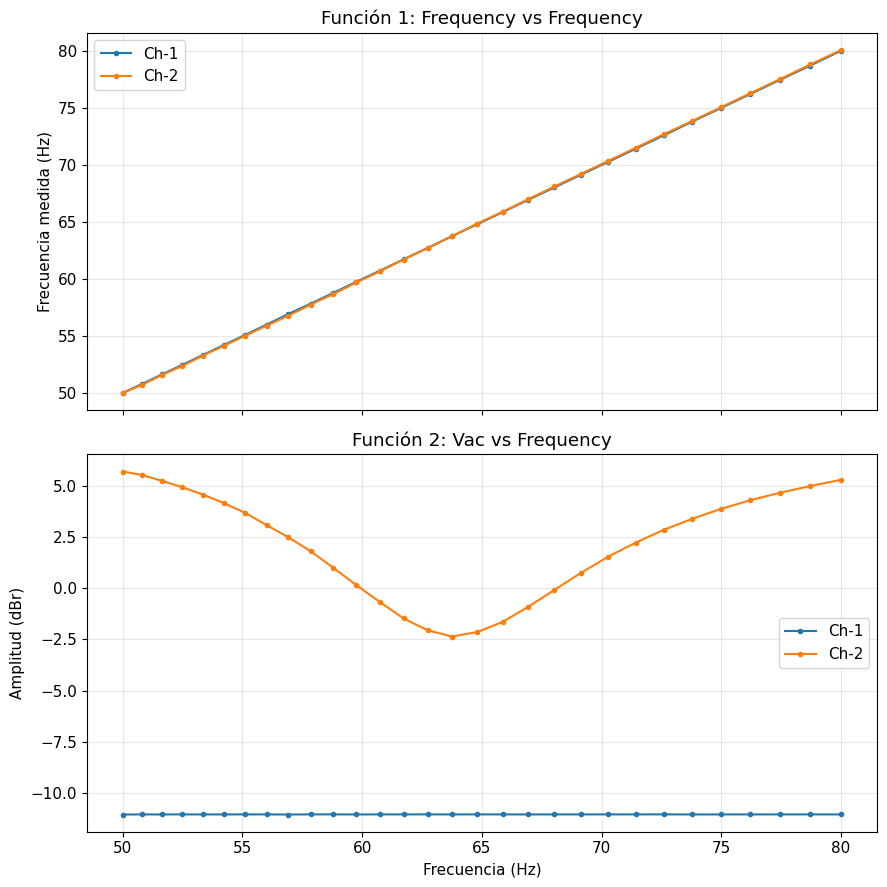

In [31]:
import os

# Obtiene la carpeta donde está guardado este notebook
script_dir = os.getcwd() 

# Une la carpeta con el nombre de tu archivo
path = os.path.join(script_dir, "Sweep_Data_10.csv")

with open(path, "r", encoding="utf-8") as f:
    raw_lines = [l.rstrip("\n") for l in f]

# El archivo tiene dos bloques ("Function 1" y "Function 2"), cada uno con:
# título, subtítulo, encabezado de columnas, y filas de datos, separados por línea vacía.
blocks = []
current = []
for line in raw_lines:
    if line.strip() == "":
        if current:
            blocks.append(current)
            current = []
    else:
        current.append(line)
if current:
    blocks.append(current)

dataframes = {}
for block in blocks:
    title = block[0].strip().strip('"')
    subtitle = block[1].strip().strip('"')
    header = [h.strip().strip('"') for h in block[2].split(",")]
    rows = [r.split(",") for r in block[3:]]
    df = pd.DataFrame(rows, columns=header).astype(float)
    dataframes[title] = (subtitle, df)
    print(f"Bloque: {title} | {subtitle} | columnas: {header} | filas: {len(df)}")

# Función 1: Frecuencia medida (Ch-1, Ch-2) vs Frecuencia programada (X)
subtitle1, df1 = dataframes["Sweep - Function 1"]
# Función 2: Amplitud (dBr) vs Frecuencia
subtitle2, df2 = dataframes["Sweep - Function 2"]

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

ax = axes[0]
ax.plot(df1["X (Hz)"], df1["Ch-1 (Hz)"], marker="o", ms=3, label="Ch-1")
ax.plot(df1["X (Hz)"], df1["Ch-2 (Hz)"], marker="o", ms=3, label="Ch-2")
ax.set_ylabel("Frecuencia medida (Hz)")
ax.set_title(f"Función 1: {subtitle1}")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(df2["X (Hz)"], df2["Ch-1 (dBr)"], marker="o", ms=3, label="Ch-1")
ax.plot(df2["X (Hz)"], df2["Ch-2 (dBr)"], marker="o", ms=3, label="Ch-2")
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Amplitud (dBr)")
ax.set_title(f"Función 2: {subtitle2}")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

## Conclusiones
- El analizador de audio refleja resultados no calibrados, teniendo un desplazamiento en magnitud y frecuencia. Teniendo en cuenta que nuestro ensayo particular refleja 10dB de atenuación, y el analizador de audio tiene el mayor valor en alrededor de 6dBr y el menor en -2.5dBr, podemos normalizarlo y decir que queda entre 0dB y -8.5dB, lo cual concuerda mejor con los resultados obtenidos previamente.
- El ensayo nos permite denotar que se pudo obtener la transferencia buscada, aunque con fuertes distorciones debido a falta de ajuste preciso. La frecuencia no pudo ser graficada por falta de datos, el analizador de audio entregó la respuesta frec vs frec en vez de la respuesta en fase.
- En definitiva se pudo apreciar en el ensayo particular (no en el de audio) la forma de onda esperada tanto en módulo como fase y retardo de grupo, con serios déficits de atenuación y recorrido por la falta de ajuste fino.
- En retrospectiva haber calibrado los componentes antes de soldar sobre el PCB final hubiese dado mejores resultados, pero el ensayo cumple con el objetivo de obtener un filtro Notch, con la contra de tener atenuación de 10dB y ancho de banda de 20Hz.